# **Imports and Loading Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("train_data.csv")
df_test = pd.read_csv("test_data.csv")

## **Some Initial Insights**

In [3]:
df.head()

,id,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   881 non-null    int64  
 1   Company              881 non-null    str    
 2   Product              881 non-null    str    
 3   TypeName             881 non-null    str    
 4   Inches               881 non-null    float64
 5   ScreenResolution     881 non-null    str    
 6   CPU_Company          881 non-null    str    
 7   CPU_Type             881 non-null    str    
 8   CPU_Frequency (GHz)  881 non-null    float64
 9   RAM (GB)             881 non-null    int64  
 10  Memory               881 non-null    str    
 11  GPU_Company          881 non-null    str    
 12  GPU_Type             881 non-null    str    
 13  OpSys                881 non-null    str    
 14  Weight (kg)          881 non-null    float64
 15  Price (Euro)         881 non-null    float64
dtypes

In [5]:
df.shape

(881, 16)

In [6]:
df.describe()

,id,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,881.00000,881.000000,881.000000,881.000000,881.000000,881.000000
mean,441.00000,15.085017,2.281839,8.522134,2.049714,1110.183235
std,254.46709,1.396360,0.527334,4.921176,0.657077,711.526332
min,1.00000,10.100000,0.900000,2.000000,0.690000,191.900000
25%,221.00000,14.000000,1.800000,4.000000,1.580000,589.000000
50%,441.00000,15.600000,2.500000,8.000000,2.040000,945.000000
75%,661.00000,15.600000,2.700000,8.000000,2.300000,1426.660000
max,881.00000,18.400000,3.600000,32.000000,4.700000,6099.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

id                     0
Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
dtype: int64

In [9]:
df.drop(columns=['id'], inplace=True)
df_test.drop(columns=['id'], inplace=True)

In [10]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


C:\Users\ammar\AppData\Local\Temp\ipykernel_43416\764806980.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price (Euro)'])


<Axes: xlabel='Price (Euro)', ylabel='Density'>

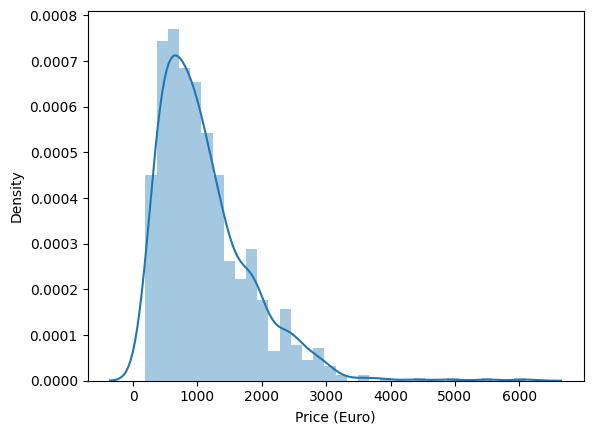

In [11]:
sns.distplot(df['Price (Euro)'])

<Axes: xlabel='Company'>

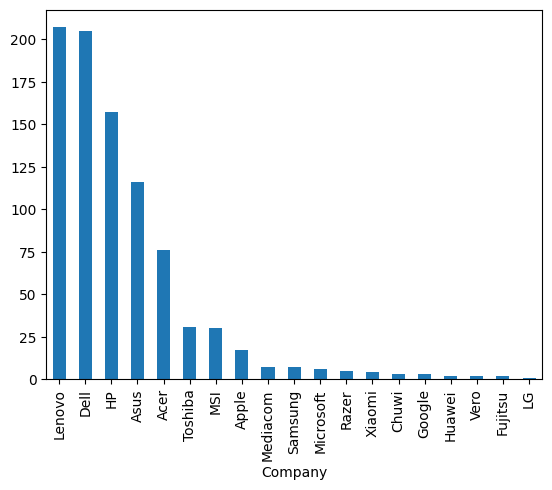

In [12]:
df['Company'].value_counts().plot(kind='bar')

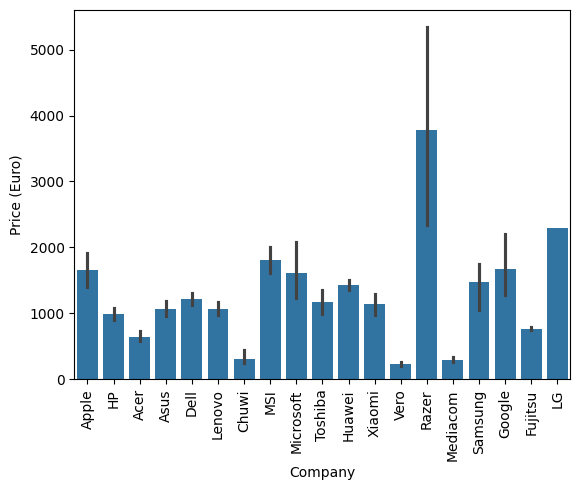

In [13]:
sns.barplot(x=df['Company'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='TypeName'>

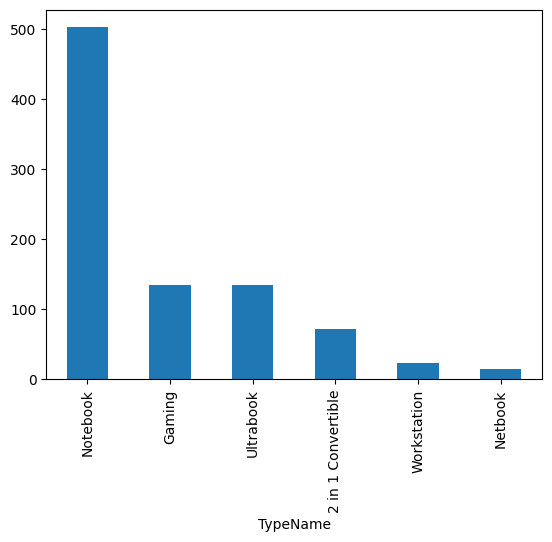

In [14]:
df['TypeName'].value_counts().plot(kind='bar')

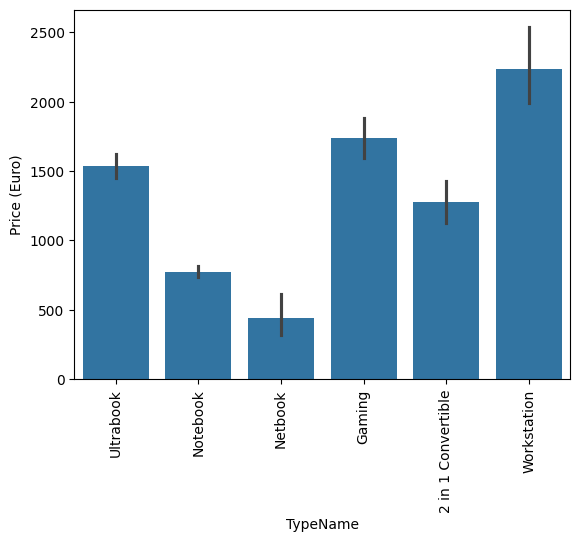

In [15]:
sns.barplot(x=df['TypeName'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

C:\Users\ammar\AppData\Local\Temp\ipykernel_43416\1439577752.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Inches'])


<Axes: xlabel='Inches', ylabel='Density'>

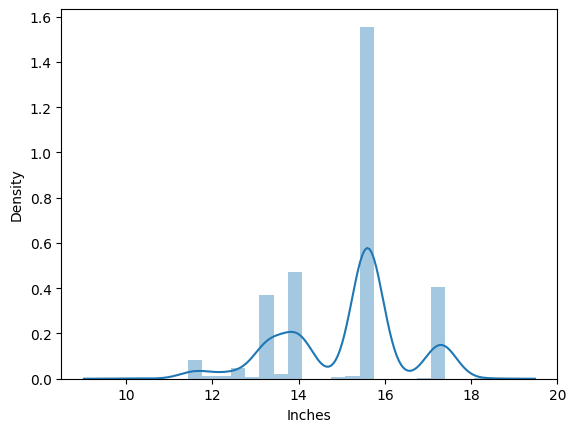

In [16]:
sns.distplot(df['Inches'])

<Axes: xlabel='Inches', ylabel='Price (Euro)'>

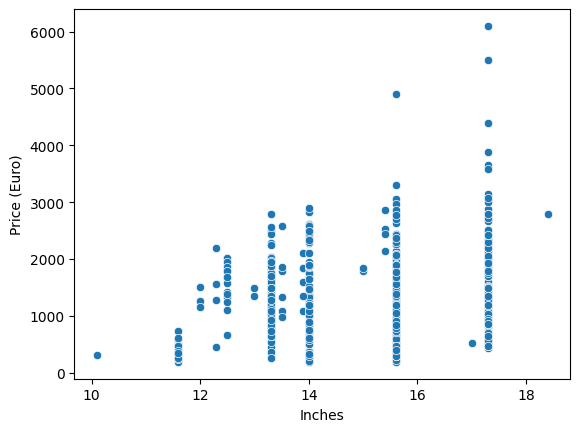

In [17]:
sns.scatterplot(x=df['Inches'],y=df['Price (Euro)'])

# **Feature Engineering**

In [18]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
df_test['Touchscreen'] = df_test['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [19]:
df.head(20)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.00,0
6,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.2,16,256GB Flash Storage,Intel,Iris Pro Graphics,Mac OS X,2.04,2139.97,0
7,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70,0
8,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,512GB SSD,Nvidia,GeForce MX150,Windows 10,1.30,1495.00,0
9,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,256GB SSD,Intel,UHD Graphics 620,Windows 10,1.60,770.00,0


<Axes: xlabel='Touchscreen'>

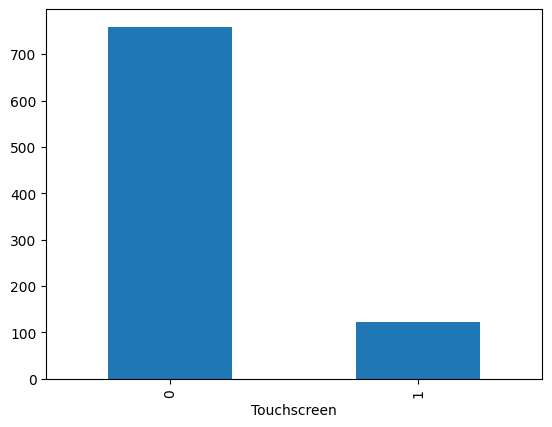

In [20]:
df['Touchscreen'].value_counts().plot(kind='bar')

<Axes: xlabel='Touchscreen', ylabel='Price (Euro)'>

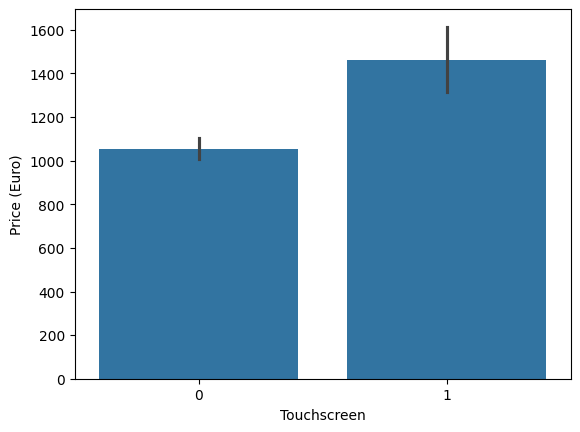

In [21]:
sns.barplot(x=df['Touchscreen'],y=df['Price (Euro)'])

In [22]:
df['Ips'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)
df_test['Ips'] = df_test['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [23]:
df.head(10)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.00,0,0
6,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.2,16,256GB Flash Storage,Intel,Iris Pro Graphics,Mac OS X,2.04,2139.97,0,1
7,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70,0,0
8,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,512GB SSD,Nvidia,GeForce MX150,Windows 10,1.30,1495.00,0,0
9,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,256GB SSD,Intel,UHD Graphics 620,Windows 10,1.60,770.00,0,1


<Axes: xlabel='Ips'>

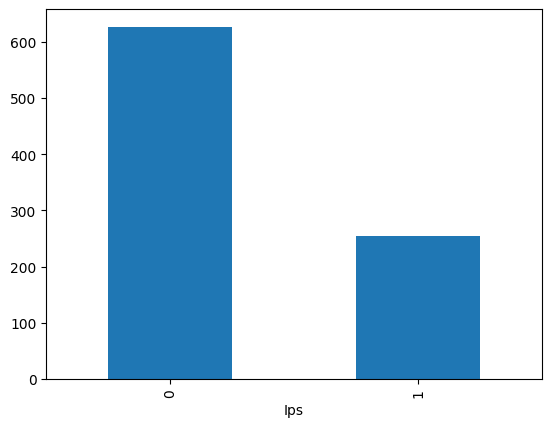

In [24]:
df['Ips'].value_counts().plot(kind='bar')

<Axes: xlabel='Ips', ylabel='Price (Euro)'>

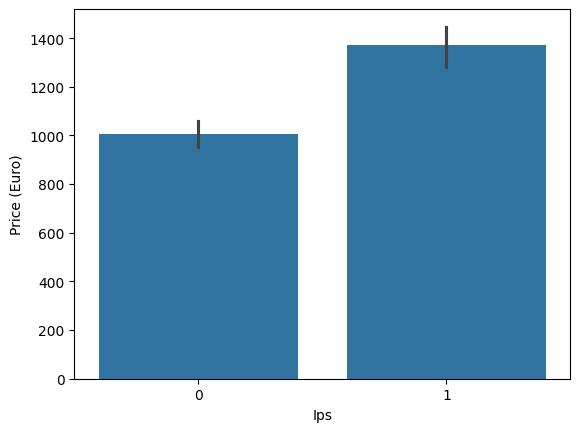

In [25]:
sns.barplot(x=df['Ips'],y=df['Price (Euro)'])

<div style="padding:15px; background-color: #fff3cd; border: 2px solid #ffeeba; color: #856404; border-radius: 5px;">
  <h2>⚠️ OLD
 CELLS ⚠️</h2>
  The 2 OLD cells
</div>

In [26]:
# new = df['ScreenResolution'].str.extract(r'(\d+)x(\d+)')
# new = df_test['ScreenResolution'].str.extract(r'(\d+)x(\d+)')

In [27]:
# df['X'] = new[0].astype(int)
# df['Y'] = new[1].astype(int)
# df_test['X'] = new[0].astype(int)
# df_test['Y'] = new[1].astype(int)

<div style="padding:15px; background-color: #c6ffb5ff; border: 2px solid #ffeeba; color: #856404; border-radius: 5px;">
  <h2>⚠️ New Cells ⚠️</h2>
  The New cells
</div>

In [28]:
# For Train dataset
resolution = df['ScreenResolution'].str.extract(r'(\d+)[xX](\d+)')
df['X'] = resolution[0].astype(int)
df['Y'] = resolution[1].astype(int)

df['ppi'] = ((df['X']**2 + df['Y']**2)**0.5)/ df['Inches']

# For test Dataset
resolution = df_test['ScreenResolution'].str.extract(r'(\d+)[xX](\d+)')
df_test['X'] = resolution[0].astype(int)
df_test['Y'] = resolution[1].astype(int)

df_test['ppi'] = ((df_test['X']**2 + df_test['Y']**2)**0.5)/ df_test['Inches']

print(df['ppi'].isnull().sum())
print(df_test['ppi'].isnull().sum())

0
0


In [29]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,X,Y,ppi
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,2560,1600,226.983005
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0,1440,900,127.677940
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0,1920,1080,141.211998
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1,2880,1800,220.534624
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1,2560,1600,226.983005


In [30]:
df["X"].value_counts()

X
1920    597
1366    184
3840     33
2560     19
1600     16
3200      9
2256      6
1440      4
2880      4
2304      3
2400      3
2160      2
2736      1
Name: count, dtype: int64

In [31]:
df.sample(10)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,X,Y,ppi
351,HP,Elitebook 850,Notebook,15.6,Full HD 1920x1080,Intel,Core i7 7500U,2.7,8,256GB SSD,Intel,HD Graphics 620,Windows 10,1.84,1304.00,0,0,1920,1080,141.211998
421,Chuwi,LapBook 12.3,Notebook,12.3,IPS Panel Retina Display 2736x1824,Intel,Celeron Quad Core N3450,1.1,6,64GB Flash Storage,Intel,HD Graphics 500,Windows 10,1.40,449.00,0,1,2736,1824,267.338436
770,Dell,Inspiron 5567,Notebook,15.6,Full HD 1920x1080,Intel,Core i7 7500U,2.7,16,256GB SSD,AMD,Radeon R7 M445,Windows 10,2.30,1181.27,0,0,1920,1080,141.211998
139,HP,Envy 13-AD007nv,Notebook,13.3,IPS Panel Full HD 1920x1080,Intel,Core i5 7200U,2.5,4,256GB SSD,Intel,HD Graphics 620,Windows 10,1.32,699.00,0,1,1920,1080,165.632118
310,Lenovo,IdeaPad 720S-13IKB,Notebook,13.3,IPS Panel Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,Windows 10,1.10,999.00,0,1,1920,1080,165.632118
290,Acer,Chromebook C910-C2ST,Notebook,15.6,1366x768,Intel,Celeron Dual Core 3205U,1.5,2,16GB SSD,Intel,HD Graphics,Chrome OS,2.19,199.00,0,0,1366,768,100.454670
316,HP,Spectre x360,2 in 1 Convertible,13.3,IPS Panel 4K Ultra HD / Touchscreen 3840x2160,Intel,Core i7 8550U,1.8,16,1TB SSD,Intel,UHD Graphics 620,Windows 10,1.29,2449.00,1,1,3840,2160,331.264236
242,Asus,F756UX-T4201D (i7-7500U/8GB/128GB,Notebook,17.3,Full HD 1920x1080,Intel,Core i7 7500U,2.7,8,128GB SSD + 1TB HDD,Nvidia,GeForce GTX 950M,No OS,2.69,889.00,0,0,1920,1080,127.335675
503,Lenovo,IdeaPad 320-14IAP,Notebook,14.0,1366x768,Intel,Celeron Dual Core N3350,1.1,4,500GB HDD,Intel,HD Graphics 500,Windows 10,2.10,299.00,0,0,1366,768,111.935204
582,HP,ProBook 430,Notebook,13.3,Full HD 1920x1080,Intel,Core i3 7100U,2.4,4,128GB SSD,Intel,HD Graphics 620,Windows 10,1.49,719.00,0,0,1920,1080,165.632118


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              881 non-null    str    
 1   Product              881 non-null    str    
 2   TypeName             881 non-null    str    
 3   Inches               881 non-null    float64
 4   ScreenResolution     881 non-null    str    
 5   CPU_Company          881 non-null    str    
 6   CPU_Type             881 non-null    str    
 7   CPU_Frequency (GHz)  881 non-null    float64
 8   RAM (GB)             881 non-null    int64  
 9   Memory               881 non-null    str    
 10  GPU_Company          881 non-null    str    
 11  GPU_Type             881 non-null    str    
 12  OpSys                881 non-null    str    
 13  Weight (kg)          881 non-null    float64
 14  Price (Euro)         881 non-null    float64
 15  Touchscreen          881 non-null    int64  
 16  I

<Axes: xlabel='ppi', ylabel='Price (Euro)'>

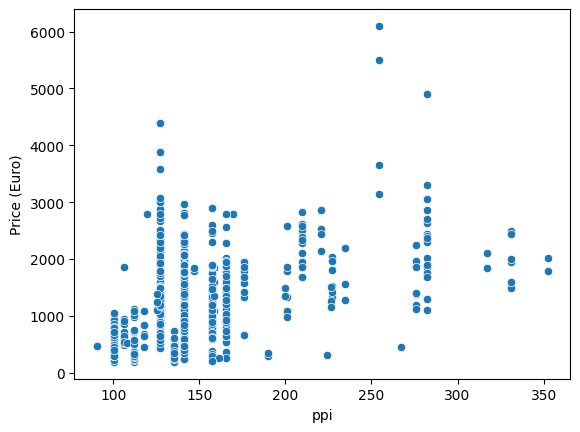

In [33]:
sns.scatterplot(x=df['ppi'],y=df['Price (Euro)'])

In [34]:
df['X'].sample(10)

549    1920
680    1920
705    1920
331    1920
57     1366
474    3840
711    1920
348    1366
409    1366
717    1366
Name: X, dtype: int64

In [35]:
df.corr(numeric_only=True)['Price (Euro)']

Inches                 0.092347
CPU_Frequency (GHz)    0.451539
RAM (GB)               0.784077
Weight (kg)            0.241972
Price (Euro)           1.000000
Touchscreen            0.198150
Ips                    0.232332
X                      0.574924
Y                      0.572712
ppi                    0.490622
Name: Price (Euro), dtype: float64

In [36]:
df.drop(columns=['ScreenResolution','Inches','X','Y'],inplace=True)
df_test.drop(columns=['ScreenResolution','Inches','X','Y'],inplace=True)

In [37]:
df.head()

,Company,Product,TypeName,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi
0,Apple,MacBook Pro,Ultrabook,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.983005
1,Apple,Macbook Air,Ultrabook,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0,127.677940
2,HP,250 G6,Notebook,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0,141.211998
3,Apple,MacBook Pro,Ultrabook,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1,220.534624
4,Apple,MacBook Pro,Ultrabook,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1,226.983005


In [38]:
df.drop(columns=['Product'],inplace=True)
df_test.drop(columns=['Product'],inplace=True)

In [39]:
df['CPU_Company'].value_counts().head(50)

CPU_Company
Intel    835
AMD       46
Name: count, dtype: int64

In [40]:
df['CPU_Type'].value_counts().head(50)

CPU_Type
Core i5 7200U              134
Core i7 7700HQ             117
Core i7 7500U               91
Core i7 8550U               71
Core i5 8250U               71
Core i3 6006U               63
Core i5 7300HQ              28
Celeron Dual Core N3350     27
Core i3 7100U               24
Core i5 6200U               22
Celeron Dual Core N3060     17
Core i7 6500U               13
Core i7 7600U               12
Core i5 7300U               12
Core i5                     11
A9-Series 9420              11
Pentium Quad Core N4200     11
Core i7 6700HQ               9
Core i3 7130U                8
Core i7 7820HK               7
A6-Series 9220               6
Pentium Quad Core N3710      6
Atom x5-Z8350                5
Core i7 6600U                5
Core i7 7820HQ               5
Celeron Quad Core N3450      5
Core i7                      4
A12-Series 9720P             4
Core i7 6820HQ               4
Core i5 7440HQ               4
Core i7 6820HK               4
Ryzen 1700                   3

<div style="padding:15px; background-color: #c6ffb5ff; border: 2px solid #ffeeba; color: #856404; border-radius: 5px;">
  <h2>⚠️ New Cells ⚠️</h2>
  The New cells
</div>

In [41]:
########################### NEW CONTENT ###########################
# def fetch_processor(text):
#     if 'Core i7' in text:
#         return 'Intel Core i7'
#     elif 'Core i5' in text:
#         return 'Intel Core i5'
#     elif 'Core i3' in text:
#         return 'Intel Core i3'
#     elif text.split()[0] == 'Intel':
#         return 'Other Intel Processor'
#     else:
#         return 'AMD Processor'


In [42]:
# df['CPU Name'] = df['CPU_Company'] + ' ' + df['CPU_Type']
# df_test['CPU Name'] = df_test['CPU_Company'] + ' ' + df_test['CPU_Type']


In [43]:
# df.head()

In [44]:
# df['CPU'] = df['CPU Name'].apply(fetch_processor)
# df_test['CPU'] = df_test['CPU Name'].apply(fetch_processor)

In [45]:
# df['CPU'].value_counts()

In [46]:
# df.drop(columns=['CPU Name'],inplace=True)
# df_test.drop(columns=['CPU Name'],inplace=True)

In [47]:
# df.head()

<div style="padding:15px; background-color: #fff3cd; border: 2px solid #ffeeba; color: #856404; border-radius: 5px;">
  <h2>⚠️ OLD
 CELLS ⚠️</h2>
</div>

In [48]:
df['CPU'] = df['CPU_Type'].str.extract(r'(Core i[3579]|Core M|Ryzen|Xeon|Celeron|Pentium|Atom|A\d+-Series|E-Series|FX)')
df_test['CPU'] = df_test['CPU_Type'].str.extract(r'(Core i[3579]|Core M|Ryzen|Xeon|Celeron|Pentium|Atom|A\d+-Series|E-Series|FX)')

In [49]:
df['CPU'].value_counts().head(50)

CPU
Core i7       350
Core i5       292
Core i3        98
Celeron        57
Pentium        19
A9-Series      13
Atom            8
A6-Series       8
Core M          7
E-Series        7
A10-Series      6
A12-Series      5
Ryzen           4
Xeon            4
A8-Series       2
FX              1
Name: count, dtype: int64

<Axes: xlabel='CPU'>

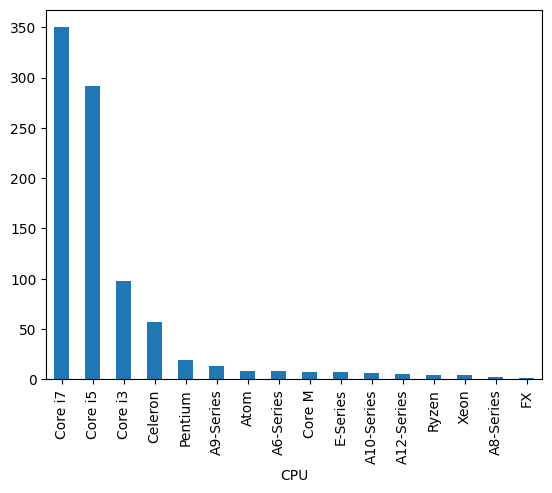

In [50]:
df['CPU'].value_counts().plot(kind='bar')

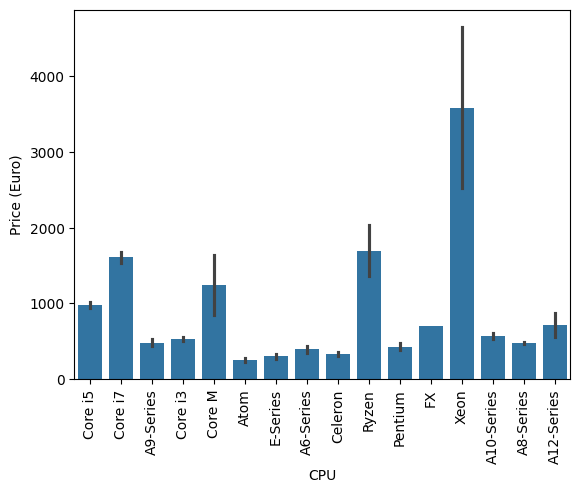

In [51]:
sns.barplot(x=df['CPU'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='RAM (GB)'>

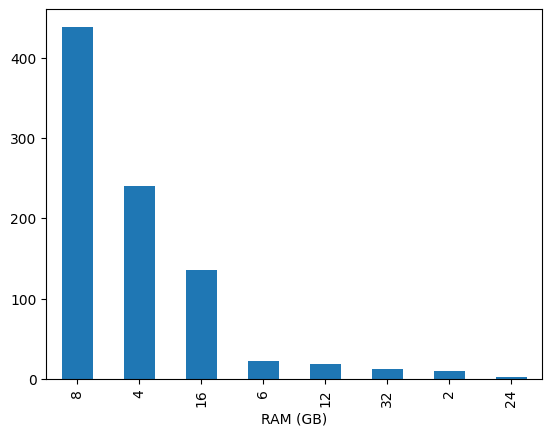

In [52]:
df['RAM (GB)'].value_counts().plot(kind='bar')

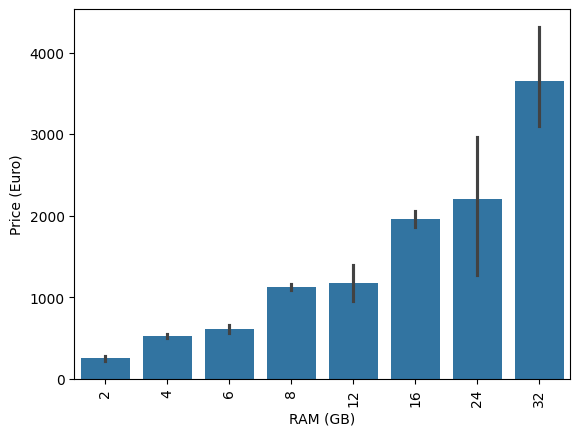

In [53]:
sns.barplot(x=df['RAM (GB)'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

In [54]:
df['Memory'].value_counts()

Memory
256GB SSD                        287
1TB HDD                          155
512GB SSD                         83
500GB HDD                         69
128GB SSD +  1TB HDD              63
128GB SSD                         59
256GB SSD +  1TB HDD              48
32GB Flash Storage                25
2TB HDD                           14
256GB SSD +  2TB HDD              10
512GB SSD +  1TB HDD              10
1TB SSD                           10
64GB Flash Storage                 8
32GB SSD                           5
16GB Flash Storage                 5
128GB Flash Storage                4
256GB Flash Storage                4
180GB SSD                          4
128GB SSD +  2TB HDD               2
16GB SSD                           2
1TB SSD +  1TB HDD                 2
256GB SSD +  256GB SSD             1
64GB SSD                           1
1.0TB Hybrid                       1
256GB SSD +  500GB HDD             1
512GB SSD +  512GB SSD             1
512GB SSD +  256GB SSD         

In [55]:
df['Memory'] = df['Memory'].astype(str).replace(r'\.0', '', regex=True)
df["Memory"] = df["Memory"].str.replace('GB', '')
df["Memory"] = df["Memory"].str.replace('TB', '000')
new = df["Memory"].str.split("+", n = 1, expand = True)

df["first"]= new[0]
df["first"]=df["first"].str.strip()

df["second"]= new[1]

df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer1Flash_Storage"] = df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['first'] = df['first'].str.replace(r'\D', '', regex=True)

df["second"] = df["second"].fillna("0")

df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['second'] = df['second'].str.replace(r'\D', '', regex=True)

df["first"] = df["first"].astype(int)
df["second"] = df["second"].astype(int)

df["HDD"]=(df["first"]*df["Layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"]+df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1Flash_Storage"]+df["second"]*df["Layer2Flash_Storage"])

df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [56]:
df_test['Memory'] = df_test['Memory'].astype(str).replace(r'\.0', '', regex=True)
df_test["Memory"] = df_test["Memory"].str.replace('GB', '')
df_test["Memory"] = df_test["Memory"].str.replace('TB', '000')
new_test = df_test["Memory"].str.split("+", n = 1, expand = True)

df_test["first"]= new_test[0]
df_test["first"]=df_test["first"].str.strip()

df_test["second"]= new_test[1]

df_test["Layer1HDD"] = df_test["first"].apply(lambda x: 1 if "HDD" in x else 0)
df_test["Layer1SSD"] = df_test["first"].apply(lambda x: 1 if "SSD" in x else 0)
df_test["Layer1Hybrid"] = df_test["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df_test["Layer1Flash_Storage"] = df_test["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df_test['first'] = df_test['first'].str.replace(r'\D', '', regex=True)

df_test["second"] = df_test["second"].fillna("0")

df_test["Layer2HDD"] = df_test["second"].apply(lambda x: 1 if "HDD" in x else 0)
df_test["Layer2SSD"] = df_test["second"].apply(lambda x: 1 if "SSD" in x else 0)
df_test["Layer2Hybrid"] = df_test["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df_test["Layer2Flash_Storage"] = df_test["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df_test['second'] = df_test['second'].str.replace(r'\D', '', regex=True)

df_test["first"] = df_test["first"].astype(int)
df_test["second"] = df_test["second"].astype(int)

df_test["HDD"]=(df_test["first"]*df_test["Layer1HDD"]+df_test["second"]*df_test["Layer2HDD"])
df_test["SSD"]=(df_test["first"]*df_test["Layer1SSD"]+df_test["second"]*df_test["Layer2SSD"])
df_test["Hybrid"]=(df_test["first"]*df_test["Layer1Hybrid"]+df_test["second"]*df_test["Layer2Hybrid"])
df_test["Flash_Storage"]=(df_test["first"]*df_test["Layer1Flash_Storage"]+df_test["second"]*df_test["Layer2Flash_Storage"])

df_test.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [57]:
df.head()

,Company,TypeName,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,Intel,Core i5,2.3,8,128 SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.983005,Core i5,0,128,0,0
1,Apple,Ultrabook,Intel,Core i5,1.8,8,128 Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0,127.677940,Core i5,0,0,0,128
2,HP,Notebook,Intel,Core i5 7200U,2.5,8,256 SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0,141.211998,Core i5,0,256,0,0
3,Apple,Ultrabook,Intel,Core i7,2.7,16,512 SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1,220.534624,Core i7,0,512,0,0
4,Apple,Ultrabook,Intel,Core i5,3.1,8,256 SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1,226.983005,Core i5,0,256,0,0


In [58]:
df.drop(columns=['Memory'],inplace=True)
df_test.drop(columns=['Memory'],inplace=True)

In [59]:
df.corr(numeric_only=True)['Price (Euro)']

CPU_Frequency (GHz)    0.451539
RAM (GB)               0.784077
Weight (kg)            0.241972
Price (Euro)           1.000000
Touchscreen            0.198150
Ips                    0.232332
ppi                    0.490622
HDD                   -0.084962
SSD                    0.677730
Hybrid                -0.010011
Flash_Storage         -0.045146
Name: Price (Euro), dtype: float64

In [60]:
df.drop(columns=['Hybrid','Flash_Storage'],inplace=True)
df_test.drop(columns=['Hybrid','Flash_Storage'],inplace=True)

In [61]:
df['GPU_Type'].value_counts()

GPU_Type
HD Graphics 620       197
HD Graphics 520        83
UHD Graphics 620       66
GeForce GTX 1050       54
Radeon 530             37
                     ... 
Radeon R7 Graphics      1
GeForce 920             1
GeForce 940M            1
GeForce GTX 930MX       1
Radeon R7 M465          1
Name: count, Length: 92, dtype: int64

In [62]:
df['GPU_Company'].value_counts()

GPU_Company
Intel     464
Nvidia    283
AMD       134
Name: count, dtype: int64

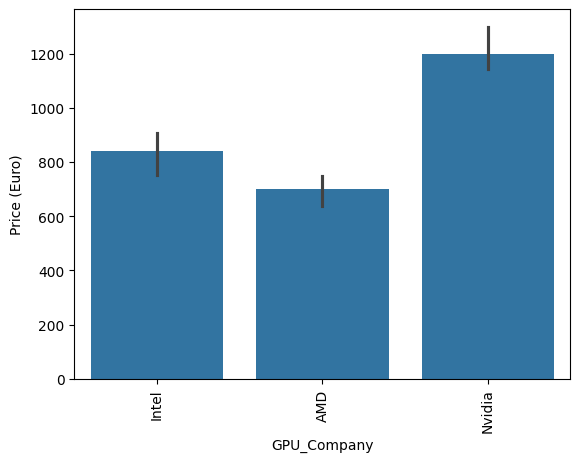

In [63]:
sns.barplot(x=df['GPU_Company'],y=df['Price (Euro)'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

In [64]:
df.drop(columns=['GPU_Type'],inplace=True)
df_test.drop(columns=['GPU_Type'],inplace=True)

In [65]:
df.drop(columns=['CPU_Type'],inplace=True)
df_test.drop(columns=['CPU_Type'],inplace=True)

In [66]:
df.sample(10)

,Company,TypeName,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,HDD,SSD
266,Asus,2 in 1 Convertible,Intel,1.8,8,Intel,Windows 10,1.10,1499.0,1,0,165.632118,Core i7,0,1024
114,Dell,Ultrabook,Intel,1.6,8,Intel,Windows 10,1.21,1629.0,0,1,165.632118,Core i5,0,256
624,HP,Notebook,Intel,2.3,4,Intel,Windows 7,1.88,932.0,0,0,100.454670,Core i5,500,0
33,Dell,Ultrabook,Intel,1.8,16,Intel,Windows 10,1.20,1869.0,1,0,276.053530,Core i7,0,512
494,Asus,Gaming,Intel,2.6,24,Nvidia,Windows 10,4.33,1269.0,1,1,127.335675,Core i7,1000,256
55,Dell,Notebook,Intel,1.8,8,AMD,Windows 10,2.13,767.8,0,0,141.211998,Core i7,0,256
819,Dell,Notebook,Intel,2.3,4,Intel,Windows 10,1.76,755.0,0,0,111.935204,Core i5,500,0
49,Asus,Notebook,Intel,1.1,4,Nvidia,Windows 10,2.80,466.0,0,0,90.583402,Pentium,1000,0
260,Dell,Notebook,Intel,1.8,8,AMD,Windows 10,2.80,1142.0,0,0,127.335675,Core i7,1000,128
140,Acer,Notebook,Intel,2.7,4,Nvidia,Windows 10,3.00,655.0,0,1,127.335675,Core i3,1000,0


In [67]:
df['TypeName'].value_counts()

TypeName
Notebook              503
Gaming                135
Ultrabook             134
2 in 1 Convertible     72
Workstation            23
Netbook                14
Name: count, dtype: int64

In [68]:
df['OpSys'].value_counts()

OpSys
Windows 10      735
No OS            50
Linux            45
Chrome OS        17
macOS            13
Windows 10 S      8
Windows 7         8
Mac OS X          4
Android           1
Name: count, dtype: int64

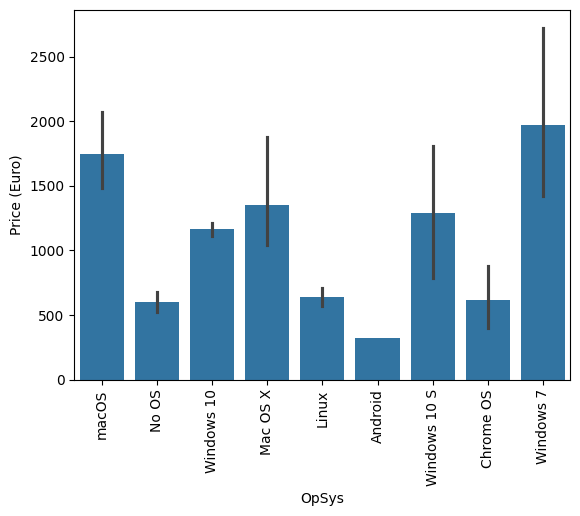

In [69]:
sns.barplot(x=df['OpSys'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

In [70]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Other'

In [71]:
df['OS'] = df['OpSys'].apply(cat_os)
df_test['OS'] = df_test['OpSys'].apply(cat_os)

In [72]:
df.head()

,Company,TypeName,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,HDD,SSD,OS
0,Apple,Ultrabook,Intel,2.3,8,Intel,macOS,1.37,1339.69,0,1,226.983005,Core i5,0,128,Mac
1,Apple,Ultrabook,Intel,1.8,8,Intel,macOS,1.34,898.94,0,0,127.677940,Core i5,0,0,Mac
2,HP,Notebook,Intel,2.5,8,Intel,No OS,1.86,575.00,0,0,141.211998,Core i5,0,256,Other
3,Apple,Ultrabook,Intel,2.7,16,AMD,macOS,1.83,2537.45,0,1,220.534624,Core i7,0,512,Mac
4,Apple,Ultrabook,Intel,3.1,8,Intel,macOS,1.37,1803.60,0,1,226.983005,Core i5,0,256,Mac


In [73]:
df.drop(columns=['OpSys'],inplace=True)
df_test.drop(columns=['OpSys'],inplace=True)

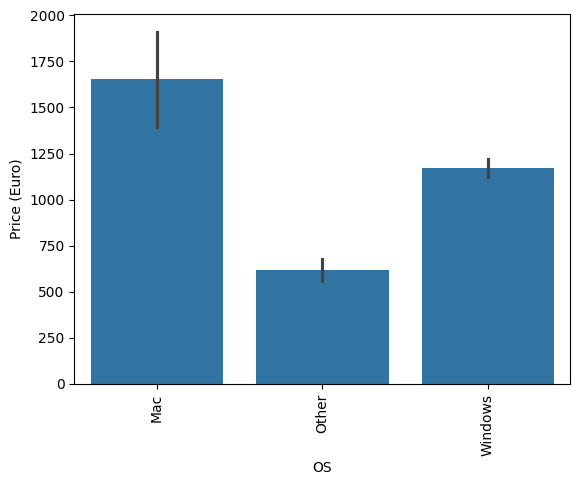

In [74]:
sns.barplot(x=df['OS'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

C:\Users\ammar\AppData\Local\Temp\ipykernel_43416\3585326794.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight (kg)'])


<Axes: xlabel='Weight (kg)', ylabel='Density'>

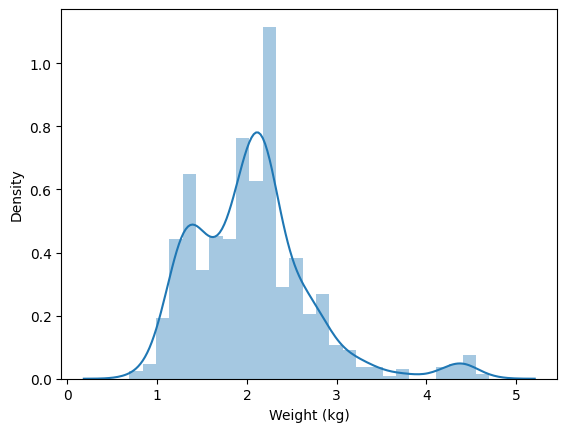

In [75]:
sns.distplot(df['Weight (kg)'])

<Axes: xlabel='Weight (kg)', ylabel='Price (Euro)'>

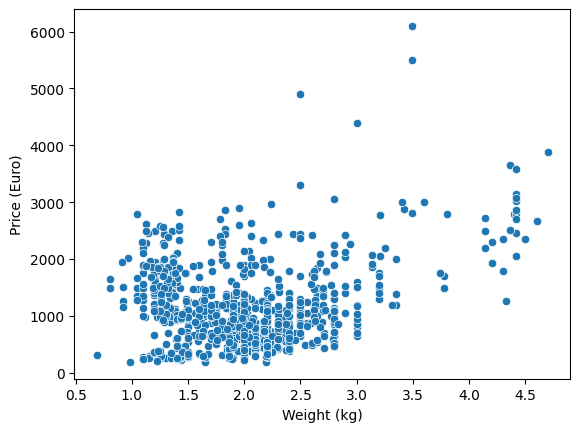

In [76]:
sns.scatterplot(x=df['Weight (kg)'],y=df['Price (Euro)'])

In [77]:
df.corr(numeric_only=True)['Price (Euro)']

CPU_Frequency (GHz)    0.451539
RAM (GB)               0.784077
Weight (kg)            0.241972
Price (Euro)           1.000000
Touchscreen            0.198150
Ips                    0.232332
ppi                    0.490622
HDD                   -0.084962
SSD                    0.677730
Name: Price (Euro), dtype: float64

# **EDA**

<Axes: >

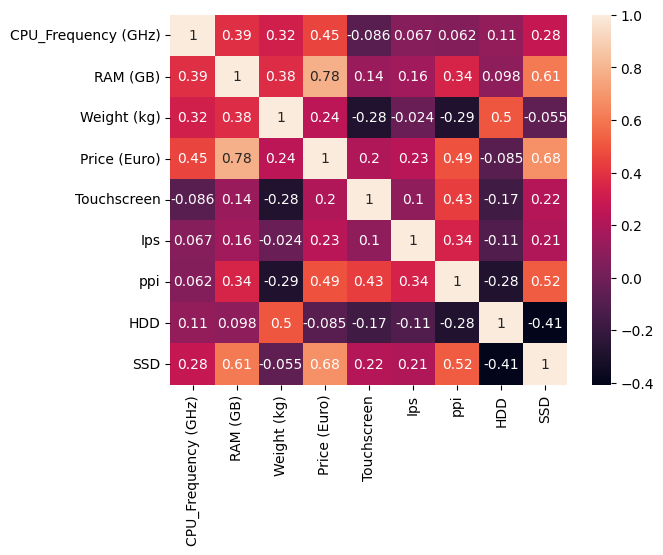

In [78]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

C:\Users\ammar\AppData\Local\Temp\ipykernel_43416\565914323.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df['Price (Euro)']))


<Axes: xlabel='Price (Euro)', ylabel='Density'>

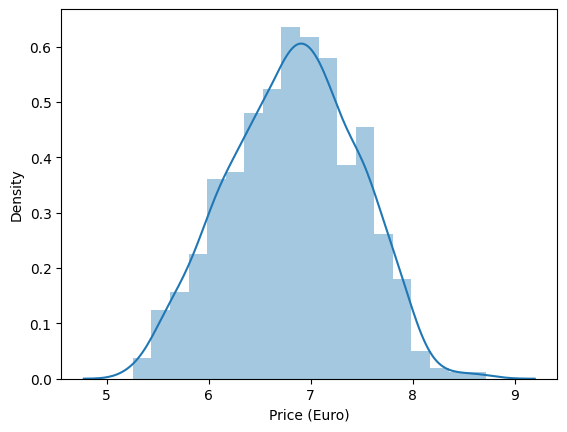

In [79]:
sns.distplot(np.log(df['Price (Euro)']))

In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              881 non-null    str    
 1   TypeName             881 non-null    str    
 2   CPU_Company          881 non-null    str    
 3   CPU_Frequency (GHz)  881 non-null    float64
 4   RAM (GB)             881 non-null    int64  
 5   GPU_Company          881 non-null    str    
 6   Weight (kg)          881 non-null    float64
 7   Price (Euro)         881 non-null    float64
 8   Touchscreen          881 non-null    int64  
 9   Ips                  881 non-null    int64  
 10  ppi                  881 non-null    float64
 11  CPU                  881 non-null    str    
 12  HDD                  881 non-null    int64  
 13  SSD                  881 non-null    int64  
 14  OS                   881 non-null    str    
dtypes: float64(4), int64(5), str(6)
memory usage: 103.4

In [81]:
df['Company'].value_counts()

Company
Lenovo       207
Dell         205
HP           157
Asus         116
Acer          76
Toshiba       31
MSI           30
Apple         17
Mediacom       7
Samsung        7
Microsoft      6
Razer          5
Xiaomi         4
Chuwi          3
Google         3
Huawei         2
Vero           2
Fujitsu        2
LG             1
Name: count, dtype: int64

# **Encoding**

In [82]:
df.nunique(np.dtype==object)

Company                 19
TypeName                 6
CPU_Company              2
CPU_Frequency (GHz)     25
RAM (GB)                 8
GPU_Company              3
Weight (kg)            157
Price (Euro)           590
Touchscreen              2
Ips                      2
ppi                     35
CPU                     16
HDD                      6
SSD                     11
OS                       3
dtype: int64

In [83]:
df = pd.get_dummies(df, columns=['Company','TypeName','CPU_Company','GPU_Company','CPU','OS'], drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Company','TypeName','CPU_Company','GPU_Company','CPU','OS'], drop_first=True)

In [84]:
df.head()

,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro),Touchscreen,Ips,ppi,HDD,SSD,Company_Apple,...,CPU_Core i3,CPU_Core i5,CPU_Core i7,CPU_E-Series,CPU_FX,CPU_Pentium,CPU_Ryzen,CPU_Xeon,OS_Other,OS_Windows
0,2.3,8,1.37,1339.69,0,1,226.983005,0,128,True,...,False,True,False,False,False,False,False,False,False,False
1,1.8,8,1.34,898.94,0,0,127.677940,0,0,True,...,False,True,False,False,False,False,False,False,False,False
2,2.5,8,1.86,575.00,0,0,141.211998,0,256,False,...,False,True,False,False,False,False,False,False,True,False
3,2.7,16,1.83,2537.45,0,1,220.534624,0,512,True,...,False,False,True,False,False,False,False,False,False,False
4,3.1,8,1.37,1803.60,0,1,226.983005,0,256,True,...,False,True,False,False,False,False,False,False,False,False


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CPU_Frequency (GHz)   881 non-null    float64
 1   RAM (GB)              881 non-null    int64  
 2   Weight (kg)           881 non-null    float64
 3   Price (Euro)          881 non-null    float64
 4   Touchscreen           881 non-null    int64  
 5   Ips                   881 non-null    int64  
 6   ppi                   881 non-null    float64
 7   HDD                   881 non-null    int64  
 8   SSD                   881 non-null    int64  
 9   Company_Apple         881 non-null    bool   
 10  Company_Asus          881 non-null    bool   
 11  Company_Chuwi         881 non-null    bool   
 12  Company_Dell          881 non-null    bool   
 13  Company_Fujitsu       881 non-null    bool   
 14  Company_Google        881 non-null    bool   
 15  Company_HP            881 non-null

In [86]:
df_test.head()

,CPU_Frequency (GHz),RAM (GB),Weight (kg),Touchscreen,Ips,ppi,HDD,SSD,Company_Apple,Company_Asus,...,CPU_Celeron,CPU_Core M,CPU_Core i3,CPU_Core i5,CPU_Core i7,CPU_E-Series,CPU_FX,CPU_Pentium,OS_Other,OS_Windows
0,2.5,4,2.30,1,0,100.454670,500,0,False,False,...,False,False,False,True,False,False,False,False,False,True
1,1.1,4,1.65,0,0,111.141337,0,0,False,True,...,True,False,False,False,False,False,False,False,False,True
2,2.5,8,2.20,0,1,141.211998,1000,0,False,False,...,False,False,False,False,True,False,False,False,False,True
3,1.6,4,2.20,0,0,100.454670,500,0,False,False,...,False,False,False,False,False,False,False,True,False,True
4,2.5,4,1.28,1,0,165.632118,0,256,False,False,...,False,False,False,True,False,False,False,False,False,True


In [87]:
df_test.shape

(394, 45)

In [88]:
df.head()

,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro),Touchscreen,Ips,ppi,HDD,SSD,Company_Apple,...,CPU_Core i3,CPU_Core i5,CPU_Core i7,CPU_E-Series,CPU_FX,CPU_Pentium,CPU_Ryzen,CPU_Xeon,OS_Other,OS_Windows
0,2.3,8,1.37,1339.69,0,1,226.983005,0,128,True,...,False,True,False,False,False,False,False,False,False,False
1,1.8,8,1.34,898.94,0,0,127.677940,0,0,True,...,False,True,False,False,False,False,False,False,False,False
2,2.5,8,1.86,575.00,0,0,141.211998,0,256,False,...,False,True,False,False,False,False,False,False,True,False
3,2.7,16,1.83,2537.45,0,1,220.534624,0,512,True,...,False,False,True,False,False,False,False,False,False,False
4,3.1,8,1.37,1803.60,0,1,226.983005,0,256,True,...,False,True,False,False,False,False,False,False,False,False


# **Train-Validation Split 80/20**

In [89]:
X=df.drop(columns=['Price (Euro)'])
y=np.log(df['Price (Euro)'])

In [90]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [91]:
missing_cols = set(X.columns) - set(df_test.columns)
for c in missing_cols:
    df_test[c] = False

extra_cols = set(df_test.columns) - set(X.columns)
df_test = df_test.drop(columns=list(extra_cols))

df_test = df_test[X.columns]

In [92]:
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(df_test)

In [93]:
X_train.shape

(704, 51)

In [94]:
X_val.shape

(177, 51)

In [95]:
X_test.shape

(394, 51)

# **Model Implementation**

### **Linear Regression**

In [96]:
model = LinearRegression()
model.fit(X_train,y_train)
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

In [97]:
print("Trainig R2 Score")
print(r2_score(y_train ,y_pred_train))
print("Validation R2 Score")
print(r2_score(y_val ,y_pred_val))
print("----------------------")
print("Trainig MSE")
print(mean_squared_error(y_train ,y_pred_train))
print("Validation MSE")
print(mean_squared_error(y_val ,y_pred_val))
print("----------------------")
print("Trainig MAE")
print(mean_absolute_error(y_train ,y_pred_train))
print("Validation MAE")
print(mean_absolute_error(y_val ,y_pred_val))


Trainig R2 Score
0.8796553581139644
Validation R2 Score
0.8683558792307019
----------------------
Trainig MSE
0.04481574845578173
Validation MSE
0.05729274447261689
----------------------
Trainig MAE
0.16705649821682272
Validation MAE
0.1901163480247836


### **Polynomial Regression**

### **Ridge Regression**

### **Lasso Regression**

### **Regression Trees**